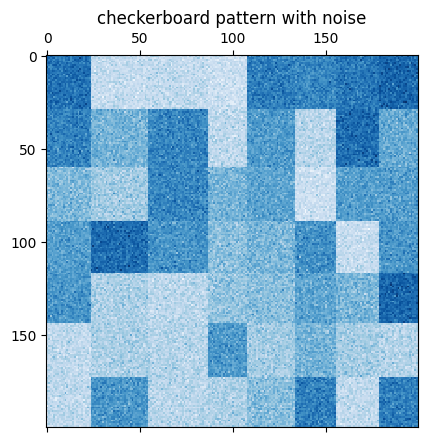

In [ ]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_checkerboard
from sklearn.metrics import consensus_score\

n_clusters = (7,8)
data,rows,columns = make_checkerboard(
    shape=(200,200), n_clusters=n_clusters,noise=10, shuffle=False, random_state=0
)
plt.matshow(
    data, cmap = plt.cm.Blues
)
plt.title("checkerboard pattern with noise")
plt.show()

In [2]:
import numpy as np
# create a shuffed in the make_checkerboard
rng = np.random.RandomState(0)
row_idx_shuffled = rng.permutation(data.shape[0])
col_idx_shuffled = rng.permutation(data.shape[1])


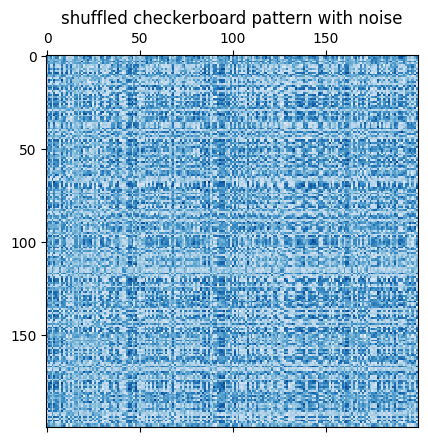

In [4]:
data = data[row_idx_shuffled][:,col_idx_shuffled]
plt.matshow(
    data, cmap =plt.cm.Blues
)
plt.title("shuffled checkerboard pattern with noise")
plt.show()

In [8]:
from sklearn.cluster import SpectralBiclustering
from sklearn.metrics import consensus_score
model = SpectralBiclustering(
    n_clusters=n_clusters, method='scale', random_state=42
)
model.fit(data)
score = consensus_score(
    model.biclusters_, (rows[:,row_idx_shuffled], columns[:,col_idx_shuffled])

)
print(f"consensus score: {score:.1f}")

consensus score: 0.0


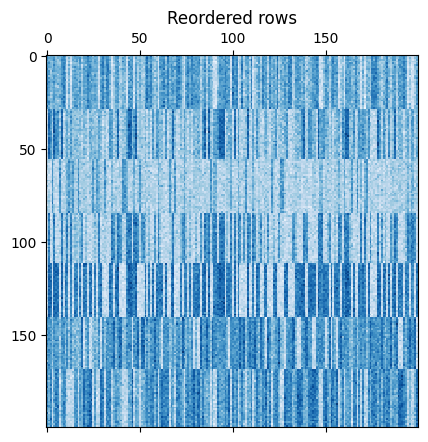

In [9]:
reordered_rows = data[np.argsort(model.row_labels_)]
reordered_columns = data[:, np.argsort(model.column_labels_)]
plt.matshow(
    reordered_rows,cmap=plt.cm.Blues
)
plt.title("Reordered rows")
plt.show()

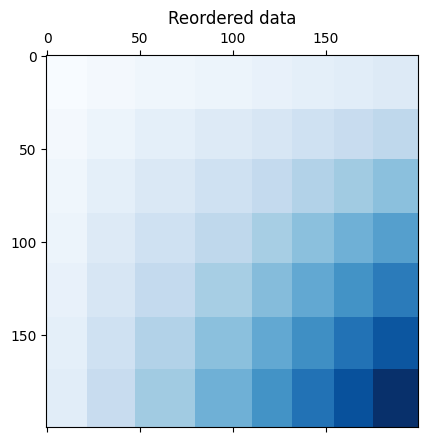

In [10]:
plt.matshow(
    np.outer(
        np.sort(model.row_labels_) +1,
        np.sort(model.column_labels_) +1
    ),
        cmap =plt.cm.Blues

)
plt.title("Reordered data")
plt.show()